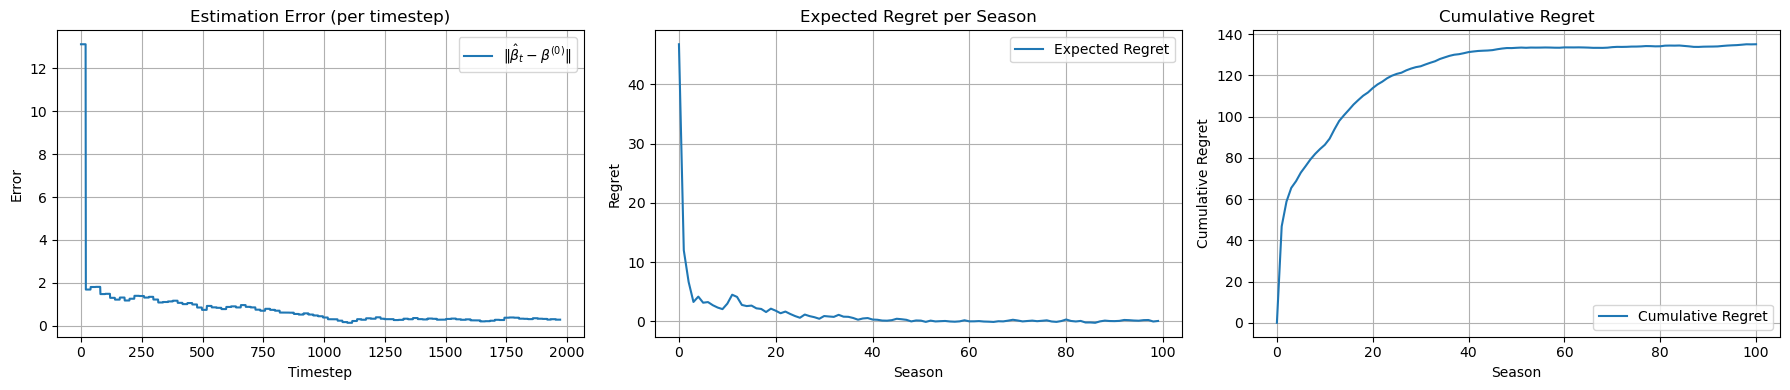

In [3]:
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from tqdm import tqdm
# Parameters
C = 10            # Initial inventory
S = 20            # Time periods per season
T = 100           # Seasons
M = 10000          # Monte Carlo simulations per season for expected regret
pl, ph = 1, 20    # Price bounds
eps = (ph - pl) / 10
beta_true = np.array([2.0, -0.4])
prices_grid = np.linspace(pl, ph, 200)

# Demand probability (logit)
def demand_prob(p, beta):
    z = beta[0] + beta[1] * p
    return 1 / (1 + np.exp(-z))

# Value Iteration for CEQ policy
def compute_optimal_policy(beta):
    V = np.zeros((C + 1, S + 2))
    policy = np.zeros((C + 1, S + 1))

    for s in range(S, 0, -1):
        for c in range(1, C + 1):
            best_val, best_p = -np.inf, None
            for p in prices_grid:
                d_prob = demand_prob(p, beta)
                expected_revenue = (
                    p * d_prob +
                    d_prob * V[c - 1, s + 1] +
                    (1 - d_prob) * V[c, s + 1]
                )
                if expected_revenue > best_val:
                    best_val = expected_revenue
                    best_p = p
            V[c, s] = best_val
            policy[c, s] = best_p
    return policy, V

# Check if all prices are within epsilon
def within_eps(prices, target, eps):
    return all(abs(p - target) < eps for p in prices)

# Initialize
X, y = [], []
regrets, beta_errors = [], []
beta_hat = np.array([10.0, 10.0])
beta_error_timestep = []
policies = []
# Step 1: Initialize with 2 prices for both classes
init_prices = [2., 10.]
for p in init_prices:
    d = np.random.binomial(1, demand_prob(p, beta_true))
    X.append([1, p])
    y.append(d)

# Step 2: Compute V_star once (true expected optimal revenue)
_, V_opt_true = compute_optimal_policy(beta_true)
V_star = V_opt_true[C, 1]

# Main loop over T seasons
for t in range(T):
    # Step 3: Compute CEQ policy with current estimate
    policy, _ = compute_optimal_policy(beta_hat)

    prices_this_season = []
    c = C
    for s in range(1, S + 1):
        if c == 0:
            break

        p_ceq = policy[c, s]

        # Exploration logic
        same_season_prices = [p for (p, ss) in prices_this_season if ss == s]
        cond_a = all(abs(p1 - p2) < eps for p1 in same_season_prices for p2 in same_season_prices) if len(same_season_prices) >= 2 else True
        cond_b = within_eps(same_season_prices, p_ceq, eps)
        cond_c = c == 1 or s == S

        if cond_a and cond_b and cond_c:
            p_choices = [p_ceq + 2 * eps, p_ceq - 2 * eps]
            p_choices = [p for p in p_choices if pl <= p <= ph]
            p = np.random.choice(p_choices)
        else:
            p = p_ceq

        d = np.random.binomial(1, demand_prob(p, beta_true))
        X.append([1, p])
        y.append(d)
        prices_this_season.append((p, s))
        c = max(c - d, 0)

        # Track beta error after every time step
        beta_error_timestep.append(np.linalg.norm(beta_hat - beta_true))

    # Step 4: Expected Regret via M simulations
    expected_revenue = 0
    for _ in range(M):
        c_sim = C
        rev = 0
        for s in range(1, S + 1):
            if c_sim == 0:
                break
            p = policy[c_sim, s]
            d = np.random.binomial(1, demand_prob(p, beta_true))
            fulfilled = min(d, c_sim)
            rev += p * fulfilled
            c_sim -= fulfilled
        expected_revenue += rev
    expected_revenue /= M
    regret = V_star - expected_revenue
    regrets.append(regret)
    policies.append(np.array(policy))

    # Step 5: Fit logistic regression
    model = LogisticRegression(fit_intercept=False, solver='lbfgs')
    model.fit(X, y)
    beta_hat = model.coef_[0]

# --- Plotting ---
plt.figure(figsize=(18, 4))

# Plot 1: Estimation error vs timestep
plt.subplot(1, 3, 1)
plt.plot(beta_error_timestep, label=r"$\|\hat{\beta}_t - \beta^{(0)}\|$")
plt.title("Estimation Error (per timestep)")
plt.xlabel("Timestep")
plt.ylabel("Error")
plt.grid(True)
plt.legend()

# Plot 2: Expected regret per season
plt.subplot(1, 3, 2)
plt.plot(regrets, label="Expected Regret")
plt.title("Expected Regret per Season")
plt.xlabel("Season")
plt.ylabel("Regret")
plt.grid(True)
plt.legend()

cum_regret = np.cumsum(regrets)
# add 0 at the beginning for cumulative regret
cum_regret = np.insert(cum_regret, 0, 0)
# Plot 3: Cumulative regret
plt.subplot(1, 3, 3)
plt.plot(cum_regret, label="Cumulative Regret")
plt.title("Cumulative Regret")
plt.xlabel("Season")
plt.ylabel("Cumulative Regret")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [5]:
# regrets_boer = np.array(regrets)
# cum_regrets_boer = np.array(cum_regret)
# np.savez("regrets_boer.npz", regrets=regrets_boer, cum_regrets=cum_regrets_boer)

# estimation_error = np.array(beta_error_timestep)
# np.savez("boer_estimation_error.npz", estimation_error=estimation_error)

# policy_boer = np.array([policy[c, s] for c in range(C + 1) for s in range(S + 1)])
np.savez("policy_boer.npz", policy=policies)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [06:53<00:00,  4.14s/it]


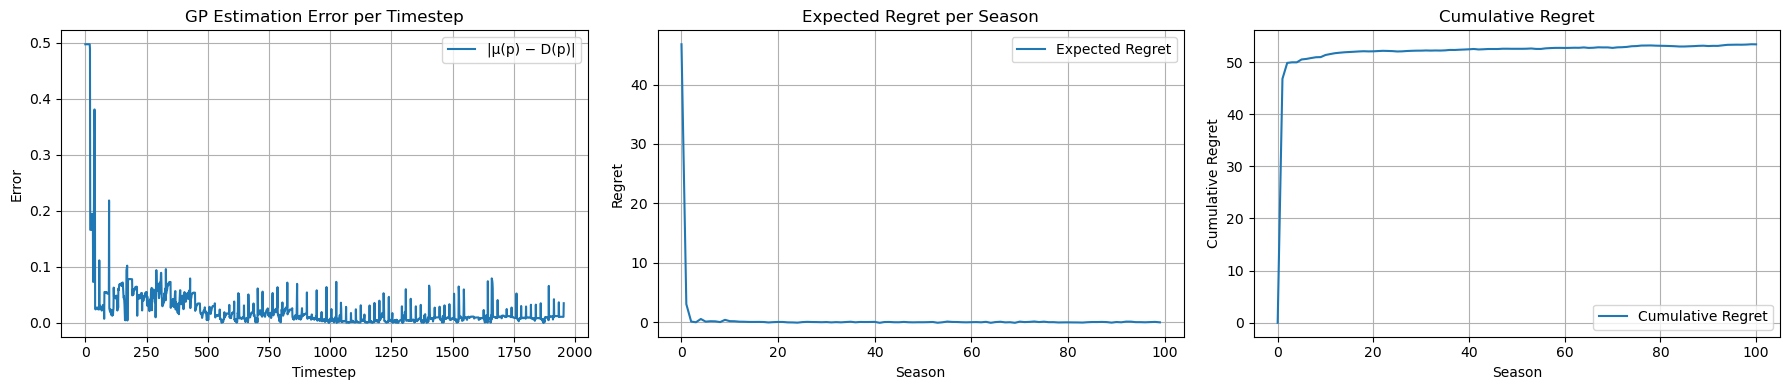

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_model
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.models.transforms import Normalize, Standardize
from tqdm import tqdm

# Set default precision to float64
torch.set_default_dtype(torch.float64)

# Parameters
C = 10
S = 20
T = 100
M = 50000
pl, ph = 1.0, 20.0
eps = (ph - pl) / 10
prices_grid = np.linspace(pl, ph, 200, dtype=np.float64)
beta_true = np.array([2.0, -0.4], dtype=np.float64)

# True demand model
def true_demand_prob(p):
    z = beta_true[0] + beta_true[1] * p
    return 1 / (1 + np.exp(-z))

# GP fitting with float64 and proper shapes
def fit_gp(X, y):
    train_X = torch.tensor(X, dtype=torch.float64)                    # (N, 1)
    train_Y = torch.tensor(y, dtype=torch.float64).unsqueeze(-1)  # (N, 1)

    gp = SingleTaskGP(
        train_X, train_Y,
        input_transform=Normalize(1),
        outcome_transform=Standardize(1)
    )
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_model(mll)
    return gp

# Value iteration using GP mean
def value_iteration_gp(gp):
    V = np.zeros((C + 1, S + 2))
    policy = np.zeros((C + 1, S + 1))

    price_tensor = torch.tensor(prices_grid, dtype=torch.float64).unsqueeze(-1)
    with torch.no_grad():
        mu = gp.posterior(price_tensor).mean.squeeze().numpy()

    for s in range(S, 0, -1):
        for c in range(1, C + 1):
            best_val, best_p = -np.inf, None
            for i, p in enumerate(prices_grid):
                d = mu[i]
                reward = p * d + d * V[c - 1, s + 1] + (1 - d) * V[c, s + 1]
                if reward > best_val:
                    best_val = reward
                    best_p = p
            V[c, s] = best_val
            policy[c, s] = best_p
    return policy, V

# ε-check
def within_eps(prices, target, eps):
    return all(abs(p - target) < eps for p in prices)

# Initialization
X_data, y_data = [], []
regrets, cum_rewards, gp_error_timestep = [], [0.], []
policies = []

# Seed with 2 diverse price points
init_prices = [4.0, 7.0]
for p in init_prices:
    d = np.random.binomial(1, true_demand_prob(p))
    X_data.append([p])
    y_data.append(float(d))

# Compute true V*
V_opt = np.zeros((C + 1, S + 2))
for s in range(S, 0, -1):
    for c in range(1, C + 1):
        best_val = -np.inf
        for p in prices_grid:
            d = true_demand_prob(p)
            val = p * d + d * V_opt[c - 1, s + 1] + (1 - d) * V_opt[c, s + 1]
            best_val = max(best_val, val)
        V_opt[c, s] = best_val
V_star = V_opt[C, 1]

# Main loop
for t in tqdm(range(T)):
    gp = fit_gp(X_data, y_data)
    policy, _ = value_iteration_gp(gp)

    prices_this_season = []
    c = C
    for s in range(1, S + 1):
        if c == 0:
            break

        p_ceq = policy[c, s]
        same_prices = [p for (p, ss) in prices_this_season if ss == s]
        cond_a = all(abs(p1 - p2) < eps for p1 in same_prices for p2 in same_prices) if len(same_prices) >= 2 else True
        cond_b = within_eps(same_prices, p_ceq, eps)
        cond_c = c == 1 or s == S

        if cond_a and cond_b and cond_c:
            candidates = [p_ceq + 2 * eps, p_ceq - 2 * eps]
            candidates = [p for p in candidates if pl <= p <= ph]
            p = np.random.choice(candidates)
        else:
            p = p_ceq

        d = np.random.binomial(1, true_demand_prob(p))
        X_data.append([p])
        y_data.append(float(d))
        prices_this_season.append((p, s))
        c = max(c - d, 0)

        # Error per timestep
        with torch.no_grad():
            mu_pred = gp.posterior(torch.tensor([[p]], dtype=torch.float64)).mean.item()
        gp_error_timestep.append(abs(mu_pred - true_demand_prob(p)))

    # Monte Carlo estimate of expected revenue
    total_reward = 0
    for _ in range(M):
        c_sim = C
        reward = 0
        for s in range(1, S + 1):
            if c_sim == 0:
                break
            p = policy[c_sim, s]
            d = np.random.binomial(1, true_demand_prob(p))
            fulfilled = min(d, c_sim)
            reward += p * fulfilled
            c_sim -= fulfilled
        total_reward += reward
    avg_reward = total_reward / M
    cum_rewards.append(avg_reward)
    regrets.append(V_star - avg_reward)
    policies.append(policy)


# Plotting
plt.figure(figsize=(18, 4))

plt.subplot(1, 3, 1)
plt.plot(gp_error_timestep, label="|μ(p) − D(p)|")
plt.title("GP Estimation Error per Timestep")
plt.xlabel("Timestep")
plt.ylabel("Error")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(regrets, label="Expected Regret")
plt.title("Expected Regret per Season")
plt.xlabel("Season")
plt.ylabel("Regret")
plt.grid(True)
plt.legend()

cum_regret = np.cumsum(regrets)
# add 0 at the beginning for cumulative regret
cum_regret = np.insert(cum_regret, 0, 0)
plt.subplot(1, 3, 3)
plt.plot(cum_regret, label="Cumulative Regret")
plt.title("Cumulative Regret")
plt.xlabel("Season")
plt.ylabel("Cumulative Regret")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [4]:
gp_regret = np.array(regrets)
gp_cum_regret = np.array(cum_regret)

np.savez("gp_regret_data.npz", gp_regret=gp_regret, gp_cum_regret=gp_cum_regret)
gp_error_timestep = np.array(gp_error_timestep)
np.savez("gp_error_data.npz", gp_error_timestep=gp_error_timestep)

In [5]:
gp_policy = policies
np.savez("gp_policy_data.npz", gp_policy=gp_policy)


In [32]:
print(gp_policy_norm.shape)

(100,)


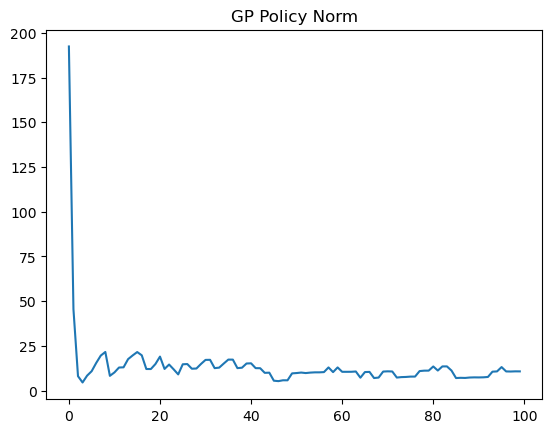

In [ ]:
gp_policy_norm = np.array([])
for policy in policies:
    pol_norm = np.linalg.norm(policy-policy_opt)
    gp_policy_norm = np.append(gp_policy_norm,pol_norm)
plt.plot(gp_policy_norm, label="GP Policy Norm")
plt.title("GP Policy Norm")
plt.show()

In [7]:
_, val = value_iteration_gp(gp)
print("GP Value Iteration Result:", val)

# total val_norm
val_norm = np.linalg.norm(val - V_opt)
print("Value Iteration Result Norm:", val_norm)



GP Value Iteration Result: [[ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          8.84844961  8.76211918  8.67274179  8.57625386  8.47180408
   8.35830984  8.23422827  8.09786323  7.94708319  7.77918792  7.59063356
   7.37664596  7.13104367  6.84500296  6.50564159  6.09385776  5.57846545
   4.90605232  3.97383551  2.55296334  0.        ]
 [ 0.         16.47123609 16.27345448 16.06088123 15.83161544 15.58334217
  15.31324274 15.01791572 14.69321661 14.33389736 13.93315931 13.48239868
  12.97027428 12.38140352 11.69485137 10.88054845  9.89475748  8.67298511
   7.11975023  5.10592667  2.55296334  0.        ]
 [ 0.         23.12505566 22.78701323 22.42346913 22.03101417 21.6055948
  21.14239585 20.63541644 20.07721205 19.45865048 18.76826928 17.99122965
  17.10832572 16.09491085 14.91

In [11]:
def demand_prob(p, beta):
    z = beta[0] + beta[1] * p
    return 1 / (1 + np.exp(-z))
def compute_optimal_policy(beta):
    V = np.zeros((C + 1, S + 2))
    policy = np.zeros((C + 1, S + 1))

    for s in range(S, 0, -1):
        for c in range(1, C + 1):
            best_val, best_p = -np.inf, None
            for p in prices_grid:
                d_prob = demand_prob(p, beta)
                expected_revenue = (
                    p * d_prob +
                    d_prob * V[c - 1, s + 1] +
                    (1 - d_prob) * V[c, s + 1]
                )
                if expected_revenue > best_val:
                    best_val = expected_revenue
                    best_p = p
            V[c, s] = best_val
            policy[c, s] = best_p
    return policy, V

gp_policy = np.array(policy)
policy_opt = compute_optimal_policy(beta_true)[0]

print("Gp Policy:", policy)
print("Optimal Policy:", policy_opt)
print("Policy Difference Norm:", np.linalg.norm(policy - policy_opt))

# ignore row 1 

policy_gp = gp_policy[2:]
policy_opt_1 = policy_opt[2:]

print("Gp Policy (ignoring row 1):", policy_gp)
print("Optimal Policy (ignoring row 1):", policy_opt_1)
print("Policy Difference Norm (ignoring row 1):", np.linalg.norm(policy_gp - policy_opt_1))

Gp Policy: [[ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.        ]
 [ 0.         20.          9.97487437  9.87939698  9.7839196   9.68844221
   9.68844221  9.59296482  9.49748744  9.40201005  9.21105528  9.11557789
   8.92462312  8.73366834  8.54271357  8.25628141  7.96984925  7.5879397
   7.01507538  6.25125628  5.10552764]
 [ 0.          9.21105528  9.11557789  9.0201005   8.92462312  8.82914573
   8.73366834  8.63819095  8.44723618  8.35175879  8.16080402  7.96984925
   7.77889447  7.49246231  7.30150754  6.91959799  6.53768844  6.06030151
   5.58291457  5.10552764  5.10552764]
 [ 0.          8.54271357  8.44723618  8.35175879  8.25628141  8.16080402
   7.96984925  7.87437186  7.68341709  7.49246231  7.30150754  7.11055276
   6.91959799  6.63316583  6.34673367  5.96482412  5.67839196  5.29648241
   5.1055

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_model
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.models.transforms import Normalize, Standardize
from tqdm import tqdm
from collections import defaultdict

# Double precision
torch.set_default_dtype(torch.float64)

# Params
C, S, T = 10, 20, 100
M = 1
pl, ph = 0.1, 20.0
bucket_width = 1.0
prices_grid = np.linspace(pl, ph, 1000, dtype=np.float64)
beta_true = np.array([2.0, -0.4], dtype=np.float64)

def true_demand(p):
    z = beta_true[0] + beta_true[1]*p
    return 1/(1 + np.exp(-z))

# --- Incremental buckets ---
bucket_sum   = defaultdict(float)
bucket_count = defaultdict(int)

def update_buckets(p, d):
    idx = int((p - pl) // bucket_width)
    bucket_sum[idx]   += d
    bucket_count[idx] += 1

def get_bucket_data():
    Xb, yb = [], []
    for idx, s in bucket_sum.items():
        ctr = pl + (idx + 0.5)*bucket_width
        Xb.append([ctr])
        yb.append(s / bucket_count[idx])
    return Xb, yb

# Fit GP on buckets
def fit_gp_buckets():
    Xb, yb = get_bucket_data()
    train_X = torch.tensor(Xb, dtype=torch.float64)
    train_Y = torch.tensor(yb, dtype=torch.float64).unsqueeze(-1)
    gp = SingleTaskGP(train_X, train_Y,
        input_transform=Normalize(1),
        outcome_transform=Standardize(1))
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_model(mll)
    return gp

# Heuristic price
def heuristic_price(gp, periods_left, current_inventory, time_step, season):
    Xtest = torch.tensor(prices_grid, dtype=torch.float64).unsqueeze(-1)
    with torch.no_grad():
        posterior = gp.posterior(Xtest)
        mu = posterior.mean.squeeze().numpy()
        var = posterior.variance.squeeze().numpy()
    # exploration bonus
    exploration = np.exp(-season * time_step / S) * var
    # expected demand
    exp_dem = periods_left * mu
    sold    = np.minimum(current_inventory, exp_dem)
    exp_rev = prices_grid * sold + exploration
    return float(prices_grid[np.argmax(exp_rev)])


def heuristic_price_fixed(mu,var, periods_left, current_inventory, time_step, season):
    
    # exploration bonus
    exploration = np.exp(-1*season * time_step) * var
    # expected demand
    exp_dem = periods_left * mu
    sold    = np.minimum(current_inventory, exp_dem)
    exp_rev = prices_grid * sold + exploration
    return float(prices_grid[np.argmax(exp_rev)])

# Seed with two points
for p in [4.0, 7.0]:
    d = np.random.binomial(1, true_demand(p))
    update_buckets(p, d)

# # Precompute true optimum V*
# V_opt = np.zeros((C+1, S+2))
# for s in range(S, 0, -1):
#     for c in range(1, C+1):
#         V_opt[c, s] = max(
#             p*true_demand(p) + true_demand(p)*V_opt[c-1, s+1] +
#             (1-true_demand(p))*V_opt[c, s+1]
#             for p in prices_grid
#         )
# V_star = V_opt[C,1]

# Simulation
regrets, errors = [], []
policies = []

for season in tqdm(range(T)):
    c = C
    gp = fit_gp_buckets()
    season_rev = 0.0
    for t in range(1, S+1):
        if c == 0:
            break
        p  = heuristic_price(gp, S-t+1, c, t, season)
        d  = np.random.binomial(1, true_demand(p))
        sold = min(d, c)
        season_rev += p * sold
        c -= sold
        update_buckets(p, d)
        # error track
        mu_pred = gp.posterior(torch.tensor([[p]], dtype=torch.float64)).mean.item()
        errors.append(abs(mu_pred - true_demand(p)))

    # MC estimate of policy revenue
    Xtest = torch.tensor(prices_grid, dtype=torch.float64).unsqueeze(-1)
    with torch.no_grad():
        posterior = gp.posterior(Xtest)
        mu   = posterior.mean.squeeze().numpy()
        var  = posterior.variance.squeeze().numpy()
    total = 0.0
    for _ in range(M):
        c_sim, rev = C, 0.0
        for t in range(1, S+1):
            if c_sim == 0: break
            p_mc = heuristic_price_fixed(mu,var, S-t+1, c_sim, t, season)
            d_mc = np.random.binomial(1, true_demand(p_mc))
            sold_mc = min(d_mc, c_sim)
            rev += p_mc * sold_mc
            c_sim -= sold_mc
        total += rev
    exp_rev = total / M
    regrets.append(V_star - exp_rev)
    policies.append(np.array([heuristic_price_fixed(mu,var, S-t+1, c_sim, t, season) for t in range(S+1) for c_sim in range(C+1)]))

# Plot
plt.figure(figsize=(18, 4))
plt.subplot(1, 3, 1)
plt.plot(errors, label="|μ(p) − D(p)|")
plt.title("GP Estimation Error per Timestep")
plt.xlabel("Timestep")
plt.ylabel("Error")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(regrets, label="Expected Regret")
plt.title("Expected Regret per Season")
plt.xlabel("Season")
plt.ylabel("Regret")
plt.grid(True)
plt.legend()

cum_regret = np.cumsum(regrets)
# add 0 at the beginning for cumulative regret
cum_regret = np.insert(cum_regret, 0, 0)
plt.subplot(1, 3, 3)
plt.plot(cum_regret, label="Cumulative Regret")
plt.title("Cumulative Regret")
plt.xlabel("Season")
plt.ylabel("Cumulative Regret")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

 63%|██████▎   | 63/100 [00:15<00:08,  4.19it/s]


KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_model
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.models.transforms import Normalize, Standardize
from tqdm import tqdm
from collections import defaultdict

# --- Setup ---
torch.set_default_dtype(torch.float64)

C, S, T = 10, 20, 100            # inventory, season length, #seasons
M = 1                        # Monte Carlo sims per season
pl, ph = 1.0, 20.0
bucket_width = 1.0               # price‐bucket width
prices_grid = np.linspace(pl, ph, 200, dtype=np.float64)
beta_true = np.array([2.0, -0.4], dtype=np.float64)

def true_demand(p):
    z = beta_true[0] + beta_true[1]*p
    return 1/(1 + np.exp(-z))

# --- Incremental Bucketing Structures ---
bucket_sum   = defaultdict(float)
bucket_count = defaultdict(int)

def update_buckets(p, d):
    idx = int((p - pl)//bucket_width)
    bucket_sum[idx]   += d
    bucket_count[idx] += 1

def get_bucket_data():
    Xb, yb = [], []
    for idx, total in bucket_sum.items():
        ctr = pl + (idx + 0.5)*bucket_width
        Xb.append([ctr])
        yb.append(total / bucket_count[idx])
    return Xb, yb

# --- GP Fit on Buckets ---
def fit_gp_buckets():
    Xb, yb = get_bucket_data()
    train_X = torch.tensor(Xb, dtype=torch.float64)
    train_Y = torch.tensor(yb, dtype=torch.float64).unsqueeze(-1)
    gp = SingleTaskGP(train_X, train_Y,
        input_transform=Normalize(1),
        outcome_transform=Standardize(1))
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_model(mll)
    return gp

# --- Transition Integration (as before) ---
from scipy.stats import norm
def compute_transition_probs(mu, sigma2, c):
    sigma = np.sqrt(sigma2)
    ps = []
    for q in range(c+1):
        lower = (q-0.5 - mu)/sigma
        upper = (q+0.5 - mu)/sigma
        if q == 0:
            p_q = norm.cdf(upper)
        elif q == c:
            p_q = 1 - norm.cdf(lower)
        else:
            p_q = norm.cdf(upper) - norm.cdf(lower)
        ps.append(p_q)
    ps = np.array(ps); ps /= ps.sum()
    return ps

# --- GP‑based Value Iteration ---
def value_iteration_gp(gp):
    V = np.zeros((C+1, S+2))
    policy = np.zeros((C+1, S+1))
    Xtest = torch.tensor(prices_grid, dtype=torch.float64).unsqueeze(-1)
    with torch.no_grad():
        post = gp.posterior(Xtest)
        mu  = post.mean.squeeze().numpy()
        var = post.variance.squeeze().numpy()
    for s in range(S, 0, -1):
        for c in range(1, C+1):
            best_val, best_p = -np.inf, None
            for i,p in enumerate(prices_grid):
                trans = compute_transition_probs(mu[i], var[i], c)
                exp_rev = 0.0
                for q,prob in enumerate(trans):
                    s_prime = c - q
                    reward = p*q
                    exp_rev += prob*(reward + V[s_prime, s+1])
                if exp_rev > best_val:
                    best_val, best_p = exp_rev, p
            V[c,s], policy[c,s] = best_val, best_p
    return policy, V

# --- Initialization & True Optimum ---
# seed two distinct prices
for p in [4.0, 7.0]:
    d = np.random.binomial(1, true_demand(p))
    update_buckets(p, d)

# compute true optimal seasonal revenue V_star
Vopt = np.zeros((C+1, S+2))
for s in range(S,0,-1):
    for c in range(1, C+1):
        Vopt[c,s] = max(
            p*true_demand(p) 
            + true_demand(p)*Vopt[c-1, s+1]
            + (1-true_demand(p))*Vopt[c, s+1]
            for p in prices_grid
        )
V_star = Vopt[C,1]

# --- Simulation ---
regrets = []; errors = [];policies = []

for season in tqdm(range(T)):
    # fit GP at season start
    gp = fit_gp_buckets()
    policy, _ = value_iteration_gp(gp)

    c, season_rev = C, 0.0
    for t in range(1, S+1):
        if c==0: break
        p = policy[c,t]
        d = np.random.binomial(1, true_demand(p))
        sold = min(d,c)
        season_rev += p*sold
        c -= sold
        update_buckets(p, d)
        # track GP error
        with torch.no_grad():
            mu_pred = gp.posterior(torch.tensor([[p]],dtype=torch.float64)).mean.item()
        errors.append(abs(mu_pred - true_demand(p)))

    # Monte Carlo expected revenue
    total=0.0
    for _ in range(M):
        c_sim, rev = C, 0.0
        for t in range(1,S+1):
            if c_sim==0: break
            p_mc = policy[c_sim,t]
            d_mc = np.random.binomial(1, true_demand(p_mc))
            sold = min(d_mc,c_sim)
            rev += p_mc*sold
            c_sim -= sold
        total+=rev
    exp_rev = total/M
    regrets.append(V_star - exp_rev)
    policies.append(np.array([policy[c,s] for c in range(C+1) for s in range(S+1)]))
# --- Plots ---
plt.figure(figsize=(18,4))
plt.subplot(131)
plt.plot(errors); plt.title("GP Error")
plt.subplot(132)
plt.plot(regrets); plt.title("Regret per Season")
plt.subplot(133)
plt.plot(np.cumsum(regrets)); plt.title("Cumulative Regret")
plt.tight_layout(); plt.show()


  0%|          | 0/100 [00:04<?, ?it/s]


KeyboardInterrupt: 

# Computation Times

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_model
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.models.transforms import Normalize, Standardize
from tqdm import tqdm
from collections import defaultdict

# Double precision
torch.set_default_dtype(torch.float64)

# Params
C, S, T = 15, 100, 100
M = 1
pl, ph = 0.1, 20.0
bucket_width = 1.0
prices_grid = np.linspace(pl, ph, 1000, dtype=np.float64)
beta_true = np.array([2.0, -0.4], dtype=np.float64)

def true_demand(p):
    z = beta_true[0] + beta_true[1]*p
    return 1/(1 + np.exp(-z))

# --- Incremental buckets ---
bucket_sum   = defaultdict(float)
bucket_count = defaultdict(int)

def update_buckets(p, d):
    idx = int((p - pl) // bucket_width)
    bucket_sum[idx]   += d
    bucket_count[idx] += 1

def get_bucket_data():
    Xb, yb = [], []
    for idx, s in bucket_sum.items():
        ctr = pl + (idx + 0.5)*bucket_width
        Xb.append([ctr])
        yb.append(s / bucket_count[idx])
    return Xb, yb

# Fit GP on buckets
def fit_gp_buckets():
    Xb, yb = get_bucket_data()
    train_X = torch.tensor(Xb, dtype=torch.float64)
    train_Y = torch.tensor(yb, dtype=torch.float64).unsqueeze(-1)
    gp = SingleTaskGP(train_X, train_Y,
        input_transform=Normalize(1),
        outcome_transform=Standardize(1))
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_model(mll)
    return gp

# Heuristic price
def heuristic_price(gp, periods_left, current_inventory, time_step, season):
    Xtest = torch.tensor(prices_grid, dtype=torch.float64).unsqueeze(-1)
    with torch.no_grad():
        posterior = gp.posterior(Xtest)
        mu = posterior.mean.squeeze().numpy()
        var = posterior.variance.squeeze().numpy()
    # exploration bonus
    exploration = np.exp(-season * time_step / S) * var
    # expected demand
    exp_dem = periods_left * mu
    sold    = np.minimum(current_inventory, exp_dem)
    exp_rev = prices_grid * sold + exploration
    return float(prices_grid[np.argmax(exp_rev)])


def heuristic_price_fixed(mu,var, periods_left, current_inventory, time_step, season):
    
    # exploration bonus
    exploration = np.exp(-1*season * time_step) * var
    # expected demand
    exp_dem = periods_left * mu
    sold    = np.minimum(current_inventory, exp_dem)
    exp_rev = prices_grid * sold + exploration
    return float(prices_grid[np.argmax(exp_rev)])

# Seed with two points
for p in [4.0, 7.0]:
    d = np.random.binomial(1, true_demand(p))
    update_buckets(p, d)

# Precompute true optimum V*
V_opt = np.zeros((C+1, S+2))
for s in range(S, 0, -1):
    for c in range(1, C+1):
        V_opt[c, s] = max(
            p*true_demand(p) + true_demand(p)*V_opt[c-1, s+1] +
            (1-true_demand(p))*V_opt[c, s+1]
            for p in prices_grid
        )
V_star = V_opt[C,1]

# Simulation
regrets, errors = [], []
policies = []

for season in tqdm(range(T)):
    c = C
    gp = fit_gp_buckets()
    season_rev = 0.0
    for t in range(1, S+1):
        if c == 0:
            break
        p  = heuristic_price(gp, S-t+1, c, t, season)
        d  = np.random.binomial(1, true_demand(p))
        sold = min(d, c)
        season_rev += p * sold
        c -= sold
        update_buckets(p, d)
        # error track
        mu_pred = gp.posterior(torch.tensor([[p]], dtype=torch.float64)).mean.item()
        errors.append(abs(mu_pred - true_demand(p)))

    # MC estimate of policy revenue
    Xtest = torch.tensor(prices_grid, dtype=torch.float64).unsqueeze(-1)
    with torch.no_grad():
        posterior = gp.posterior(Xtest)
        mu   = posterior.mean.squeeze().numpy()
        var  = posterior.variance.squeeze().numpy()
    total = 0.0
    for _ in range(M):
        c_sim, rev = C, 0.0
        for t in range(1, S+1):
            if c_sim == 0: break
            p_mc = heuristic_price_fixed(mu,var, S-t+1, c_sim, t, season)
            d_mc = np.random.binomial(1, true_demand(p_mc))
            sold_mc = min(d_mc, c_sim)
            rev += p_mc * sold_mc
            c_sim -= sold_mc
        total += rev
    exp_rev = total / M
    regrets.append(V_star - exp_rev)
    policies.append(np.array([heuristic_price_fixed(mu,var, S-t+1, c_sim, t, season) for t in range(S+1) for c_sim in range(C+1)]))




  8%|▊         | 8/100 [00:05<01:05,  1.40it/s]


KeyboardInterrupt: 

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_model
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.models.transforms import Normalize, Standardize
from tqdm import tqdm
from collections import defaultdict

# --- Setup ---
torch.set_default_dtype(torch.float64)

C, S, T = 15, 20, 100            # inventory, season length, #seasons
M = 50000                        # Monte Carlo sims per season
pl, ph = 1.0, 20.0
bucket_width = 1.0               # price‐bucket width
prices_grid = np.linspace(pl, ph, 200, dtype=np.float64)
beta_true = np.array([2.0, -0.4], dtype=np.float64)

def true_demand(p):
    z = beta_true[0] + beta_true[1]*p
    return 1/(1 + np.exp(-z))

# --- Incremental Bucketing Structures ---
bucket_sum   = defaultdict(float)
bucket_count = defaultdict(int)

def update_buckets(p, d):
    idx = int((p - pl)//bucket_width)
    bucket_sum[idx]   += d
    bucket_count[idx] += 1

def get_bucket_data():
    Xb, yb = [], []
    for idx, total in bucket_sum.items():
        ctr = pl + (idx + 0.5)*bucket_width
        Xb.append([ctr])
        yb.append(total / bucket_count[idx])
    return Xb, yb

# --- GP Fit on Buckets ---
def fit_gp_buckets():
    Xb, yb = get_bucket_data()
    train_X = torch.tensor(Xb, dtype=torch.float64)
    train_Y = torch.tensor(yb, dtype=torch.float64).unsqueeze(-1)
    gp = SingleTaskGP(train_X, train_Y,
        input_transform=Normalize(1),
        outcome_transform=Standardize(1))
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_model(mll)
    return gp

# --- Transition Integration (as before) ---
from scipy.stats import norm
def compute_transition_probs(mu, sigma2, c):
    sigma = np.sqrt(sigma2)
    ps = []
    for q in range(c+1):
        lower = (q-0.5 - mu)/sigma
        upper = (q+0.5 - mu)/sigma
        if q == 0:
            p_q = norm.cdf(upper)
        elif q == c:
            p_q = 1 - norm.cdf(lower)
        else:
            p_q = norm.cdf(upper) - norm.cdf(lower)
        ps.append(p_q)
    ps = np.array(ps); ps /= ps.sum()
    return ps

# --- GP‑based Value Iteration ---
def value_iteration_gp(gp):
    V = np.zeros((C+1, S+2))
    policy = np.zeros((C+1, S+1))
    Xtest = torch.tensor(prices_grid, dtype=torch.float64).unsqueeze(-1)
    with torch.no_grad():
        post = gp.posterior(Xtest)
        mu  = post.mean.squeeze().numpy()
        var = post.variance.squeeze().numpy()
    for s in range(S, 0, -1):
        for c in range(1, C+1):
            best_val, best_p = -np.inf, None
            for i,p in enumerate(prices_grid):
                trans = compute_transition_probs(mu[i], var[i], c)
                exp_rev = 0.0
                for q,prob in enumerate(trans):
                    s_prime = c - q
                    reward = p*q
                    exp_rev += prob*(reward + V[s_prime, s+1])
                if exp_rev > best_val:
                    best_val, best_p = exp_rev, p
            V[c,s], policy[c,s] = best_val, best_p
    return policy, V

# --- Initialization & True Optimum ---
# seed two distinct prices
for p in [4.0, 7.0]:
    d = np.random.binomial(1, true_demand(p))
    update_buckets(p, d)

# compute true optimal seasonal revenue V_star
Vopt = np.zeros((C+1, S+2))
for s in range(S,0,-1):
    for c in range(1, C+1):
        Vopt[c,s] = max(
            p*true_demand(p) 
            + true_demand(p)*Vopt[c-1, s+1]
            + (1-true_demand(p))*Vopt[c, s+1]
            for p in prices_grid
        )
V_star = Vopt[C,1]

# --- Simulation ---
regrets = []; errors = [];policies = []

for season in tqdm(range(T)):
    # fit GP at season start
    gp = fit_gp_buckets()
    policy, _ = value_iteration_gp(gp)

    c, season_rev = C, 0.0
    for t in range(1, S+1):
        if c==0: break
        p = policy[c,t]
        d = np.random.binomial(1, true_demand(p))
        sold = min(d,c)
        season_rev += p*sold
        c -= sold
        update_buckets(p, d)
        # track GP error
        with torch.no_grad():
            mu_pred = gp.posterior(torch.tensor([[p]],dtype=torch.float64)).mean.item()
        errors.append(abs(mu_pred - true_demand(p)))

    # Monte Carlo expected revenue
    total=0.0
    for _ in range(M):
        c_sim, rev = C, 0.0
        for t in range(1,S+1):
            if c_sim==0: break
            p_mc = policy[c_sim,t]
            d_mc = np.random.binomial(1, true_demand(p_mc))
            sold = min(d_mc,c_sim)
            rev += p_mc*sold
            c_sim -= sold
        total+=rev
    exp_rev = total/M
    regrets.append(V_star - exp_rev)
    policies.append(np.array([policy[c,s] for c in range(C+1) for s in range(S+1)]))
# --- Plots ---
plt.figure(figsize=(18,4))
plt.subplot(131)
plt.plot(errors); plt.title("GP Error")
plt.subplot(132)
plt.plot(regrets); plt.title("Regret per Season")
plt.subplot(133)
plt.plot(np.cumsum(regrets)); plt.title("Cumulative Regret")
plt.tight_layout(); plt.show()


  1%|          | 1/100 [01:09<1:54:10, 69.20s/it]


KeyboardInterrupt: 

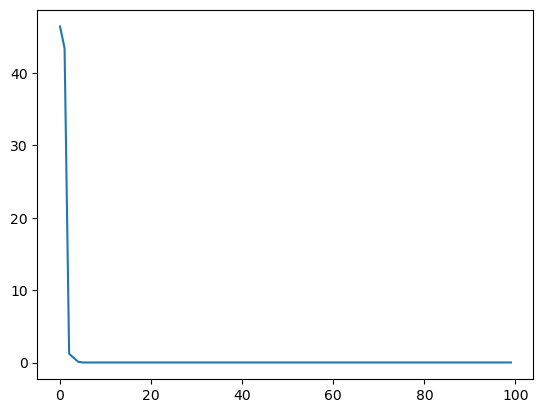

Best Regret: [4.64333235e+01 4.34222794e+01 1.23352047e+00 6.68372729e-01
 1.16422981e-01 2.31444882e-02 2.31444882e-02 2.31444882e-02
 2.31444882e-02 2.31444882e-02 2.31444882e-02 2.31444882e-02
 2.31444882e-02 2.31444882e-02 2.31444882e-02 2.31444882e-02
 2.31444882e-02 2.31444882e-02 2.31444882e-02 2.31444882e-02
 2.31444882e-02 2.31444882e-02 2.31444882e-02 2.31444882e-02
 2.31444882e-02 2.31444882e-02 2.31444882e-02 2.31444882e-02
 2.31444882e-02 2.31444882e-02 2.31444882e-02 2.31444882e-02
 2.31444882e-02 2.31444882e-02 2.31444882e-02 2.31444882e-02
 2.31444882e-02 2.31444882e-02 2.31444882e-02 2.31444882e-02
 2.31444882e-02 2.31444882e-02 2.31444882e-02 2.31444882e-02
 2.31444882e-02 2.31444882e-02 2.31444882e-02 2.31444882e-02
 2.31444882e-02 2.31444882e-02 2.31444882e-02 2.31444882e-02
 2.31444882e-02 2.31444882e-02 2.31444882e-02 2.31444882e-02
 2.31444882e-02 2.31444882e-02 2.31444882e-02 2.31444882e-02
 2.31444882e-02 2.31444882e-02 2.31444882e-02 2.31444882e-02
 2.31444882

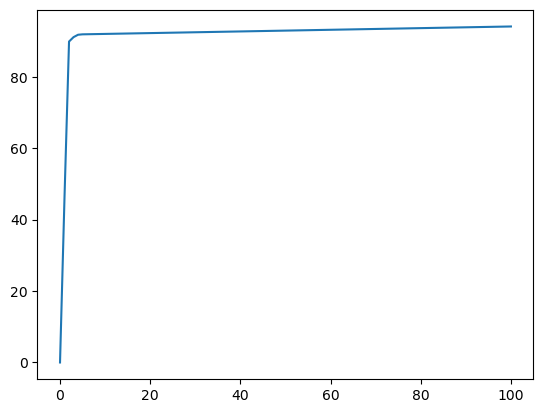

In [ ]:
best_till_now_regret = np.minimum.accumulate(regrets) 

plt.plot(best_till_now_regret, label="Best Regret")
plt.show()
print("Best Regret:", best_till_now_regret)
best_till_now_cum_regret = np.cumsum(best_till_now_regret)
best_till_now_cum_regret = np.insert(best_till_now_cum_regret, 0, 0)
plt.plot(best_till_now_cum_regret, label="Best Cumulative Regret")


In [ ]:
import numpy as np
import torch
import time
from collections import defaultdict
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_model
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.models.transforms import Normalize, Standardize
from scipy.stats import norm
import matplotlib.pyplot as plt
from itertools import product

torch.set_default_dtype(torch.float64)

T = 2  # short run for timing
pl, ph = 1.0, 20.0
bucket_width = 1.0
prices_grid = np.linspace(pl, ph, 100)
beta_true = np.array([2.0, -0.4], dtype=np.float64)

def true_demand(p):
    z = beta_true[0] + beta_true[1] * p
    return 1 / (1 + np.exp(-z))

def update_buckets(p, d, bucket_sum, bucket_count):
    idx = int((p - pl) // bucket_width)
    bucket_sum[idx] += d
    bucket_count[idx] += 1

def get_bucket_data(bucket_sum, bucket_count):
    Xb, yb = [], []
    for idx in bucket_sum:
        Xb.append([pl + (idx + 0.5) * bucket_width])
        yb.append(bucket_sum[idx] / bucket_count[idx])
    return torch.tensor(Xb), torch.tensor(yb).unsqueeze(-1)

def fit_gp_buckets(bucket_sum, bucket_count):
    X, y = get_bucket_data(bucket_sum, bucket_count)
    model = SingleTaskGP(X, y, input_transform=Normalize(1), outcome_transform=Standardize(1))
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_model(mll)
    return model

def compute_transition_probs(mu, sigma2, c):
    sigma = np.sqrt(sigma2)
    ps = []
    for q in range(c+1):
        lower = (q - 0.5 - mu) / sigma
        upper = (q + 0.5 - mu) / sigma
        if q == 0:
            ps.append(norm.cdf(upper))
        elif q == c:
            ps.append(1 - norm.cdf(lower))
        else:
            ps.append(norm.cdf(upper) - norm.cdf(lower))
    ps = np.array(ps)
    ps /= ps.sum()
    return ps

def value_iteration(gp, C, S):
    V = np.zeros((C+1, S+2))
    policy = np.zeros((C+1, S+1))
    with torch.no_grad():
        X = torch.tensor(prices_grid).unsqueeze(-1)
        mu = gp.posterior(X).mean.squeeze().numpy()
        var = gp.posterior(X).variance.squeeze().numpy()
    for s in range(S, 0, -1):
        for c in range(1, C+1):
            best_val = -np.inf
            for i, p in enumerate(prices_grid):
                trans = compute_transition_probs(mu[i], var[i], c)
                val = sum(trans[q] * (p*q + V[c-q, s+1]) for q in range(len(trans)))
                if val > best_val:
                    best_val = val
                    policy[c, s] = p
            V[c, s] = best_val
    return policy

def heuristic_price(gp, periods_left, c, t, season, S):
    with torch.no_grad():
        X = torch.tensor(prices_grid).unsqueeze(-1)
        mu = gp.posterior(X).mean.squeeze().numpy()
        var = gp.posterior(X).variance.squeeze().numpy()
    exploration = np.exp(-season * t / S) * var
    exp_demand = np.minimum(c, periods_left * mu)
    score = prices_grid * exp_demand + exploration
    return prices_grid[np.argmax(score)]

def run_experiment(algo, C, S):
    bucket_sum = defaultdict(float)
    bucket_count = defaultdict(int)
    for p in [4.0, 7.0]:
        d = np.random.binomial(1, true_demand(p))
        update_buckets(p, d, bucket_sum, bucket_count)
    # print(f"Running {algo} with C={C}, S={S}")
    start = time.time()
    for season in range(T):
        gp = fit_gp_buckets(bucket_sum, bucket_count)
        if algo == "heuristic":
            c = C
            for t in range(1, S + 1):
                if c == 0: break
                p = heuristic_price(gp, S - t + 1, c, t, season, S)
                d = np.random.binomial(1, true_demand(p))
                update_buckets(p, d, bucket_sum, bucket_count)
                c -= min(d, c)
        else:
            policy = value_iteration(gp, C, S)
            c = C
            for t in range(1, S + 1):
                if c == 0: break
                p = policy[c, t]
                d = np.random.binomial(1, true_demand(p))
                update_buckets(p, d, bucket_sum, bucket_count)
                c -= min(d, c)
    # print(f"Finished {algo} with C={C}, S={S}")
    return (time.time() - start) / T

# Configs
C_vals = [2, 5, 10, 20,30,40,50,100,200,300]
S_vals = [5, 10, 20, 30,40,50,100,200,300,500]
results = []

from tqdm import tqdm
# Run experiments and collect results
for C, S in tqdm(product(C_vals, S_vals)):
    if C >= S:
        continue
    t1 = run_experiment("heuristic", C, S)
    t2 = run_experiment("model", C, S)
    results.append((C, S, C*S, t1, t2))

# Convert to structured numpy array
results = np.array(results, dtype=[('C', int), ('S', int), ('CS', int),
                                   ('Heuristic', float), ('ModelBased', float)])
np.savez("computation_comparision.npz", results=results)

# === PLOTTING ===
plt.figure(figsize=(18, 5))

# Fix S for C vs Time (e.g., choose median S)
fixed_S = 30
subset_C = results[results['S'] == fixed_S]

plt.subplot(1, 3, 1)
plt.plot(subset_C['C'], subset_C['Heuristic'], 'o-', label='BO-Fin-Heuristic', linewidth=2)
plt.plot(subset_C['C'], subset_C['ModelBased'], 's--', label='BO-Fin-Model-Based', linewidth=2)
plt.xlabel("C (fixed S={})".format(fixed_S))
plt.ylabel("Time per Season (s)")
plt.title("Runtime vs C (S fixed)")
plt.grid(True)
plt.legend()

# Fix C for S vs Time (e.g., choose median C)
fixed_C = 10
subset_S = results[results['C'] == fixed_C]

plt.subplot(1, 3, 2)
plt.plot(subset_S['S'], subset_S['Heuristic'], 'o-', label='BO-Fin-Heuristic', linewidth=2)
plt.plot(subset_S['S'], subset_S['ModelBased'], 's--', label='BO-Fin-Model-Based', linewidth=2)
plt.xlabel("S (fixed C={})".format(fixed_C))
plt.ylabel("Time per Season (s)")
plt.title("Runtime vs S (C fixed)")
plt.grid(True)
plt.legend()

# CS vs Time using all data
plt.subplot(1, 3, 3)
plt.plot(results['CS'], results['Heuristic'], 'o-', label='BO-Fin-Heuristic', linewidth=2)
plt.plot(results['CS'], results['ModelBased'], 's--', label='BO-Fin-Model-Based', linewidth=2)
plt.xlabel("C × S")
plt.ylabel("Time per Season (s)")
plt.title("Runtime vs C×S")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()



Running heuristic with C=2, S=5


/home/anush2004/anaconda3/lib/python3.11/site-packages/botorch/models/utils/assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.]), std = tensor([0.])). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


Finished heuristic with C=2, S=5
Running model with C=2, S=5
Finished model with C=2, S=5
Running heuristic with C=2, S=10
Finished heuristic with C=2, S=10
Running model with C=2, S=10


/home/anush2004/anaconda3/lib/python3.11/site-packages/botorch/models/utils/assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.]), std = tensor([0.])). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)
/home/anush2004/anaconda3/lib/python3.11/site-packages/botorch/models/utils/assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.]), std = tensor([0.])). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


Finished model with C=2, S=10
Running heuristic with C=2, S=20
Finished heuristic with C=2, S=20
Running model with C=2, S=20


...

Finished model with C=20, S=500
Running heuristic with C=30, S=40


/home/anush2004/anaconda3/lib/python3.11/site-packages/botorch/models/utils/assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.]), std = tensor([0.])). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)
/home/anush2004/anaconda3/lib/python3.11/site-packages/botorch/models/utils/assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.]), std = tensor([0.])). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


Finished heuristic with C=30, S=40
Running model with C=30, S=40


/home/anush2004/anaconda3/lib/python3.11/site-packages/botorch/models/utils/assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([0.]), std = tensor([0.])). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


Finished model with C=30, S=40
Running heuristic with C=30, S=50
Finished heuristic with C=30, S=50
Running model with C=30, S=50


In [4]:
from itertools import product

C_vals = [2, 5, 10,30,50,100,200]
S_vals = [5, 10, 30,50,100,200,300]
results = []

from tqdm import tqdm
i=0
# Run experiments and collect results
for C, S in tqdm(product(C_vals, S_vals)):
    print(C, S)

    if C >= S:
        continue
    # print(i)
    # i+=1

49it [00:00, 123510.15it/s]

2 5
2 10
2 30
2 50
2 100
2 200
2 300
5 5
5 10
5 30
5 50
5 100
5 200
5 300
10 5
10 10
10 30
10 50
10 100
10 200
10 300
30 5
30 10
30 30
30 50
30 100
30 200
30 300
50 5
50 10
50 30
50 50
50 100
50 200
50 300
100 5
100 10
100 30
100 50
100 100
100 200
100 300
200 5
200 10
200 30
200 50
200 100
200 200
200 300
